<a href="https://colab.research.google.com/github/miasilviayuliati-sys/Tugas1-PCD/blob/main/PCD_Tugas4(Filter).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA : MIA SILVIA YULIATI

NIM : 23424053

KELAS : IF24A

In [1]:
import numpy as np

# Kernel (H)
H = np.array([
    [1, 1, 1],
    [1, 4, 1],
    [1, 1, 1]
])

# Input (X)
X = np.array([
    [1, 0, 0, 0],
    [1, 1, 1, 0],
    [1, 1, 1, 0],
    [1, 0, 0, 0]
])

# Ukuran
h_k, w_k = H.shape
h_x, w_x = X.shape

# Padding supaya ukuran tetap
pad = h_k // 2
X_padded = np.pad(X, pad, mode='constant', constant_values=0)

# Output
Y = np.zeros((h_x, w_x))

# Proses konvolusi
for i in range(h_x):
    for j in range(w_x):
        total = 0
        for u in range(-1, 2):
            for v in range(-1, 2):
                total += H[u+1][v+1] * X_padded[i+u+pad][j+v+pad]
        Y[i][j] = total

# Hasil
print("Hasil Konvolusi:")
print(Y)

Hasil Konvolusi:
[[ 6.  4.  2.  1.]
 [ 8. 10.  7.  2.]
 [ 8. 10.  7.  2.]
 [ 6.  4.  2.  1.]]


In [2]:
import numpy as np
from scipy.signal import convolve2d

# ======================
# 1. Input Matrix X
# ======================
X = np.array([
    [1, 0, 0, 0],
    [1, 1, 1, 0],
    [1, 1, 1, 0],
    [1, 0, 0, 0]
])

print("Matrix X:")
print(X)

# ======================
# 2. LOW-PASS FILTER
# ======================
H_low = np.array([
    [1, 1, 1],
    [1, 4, 1],
    [1, 1, 1]
])

# Normalisasi
H_low = H_low / 12

Y_low = convolve2d(X, H_low, mode='same', boundary='fill', fillvalue=0)

print("\nHasil Low-Pass:")
print(np.round(Y_low, 3))


# ======================
# 3. HIGH-PASS FILTER
# ======================
H_high = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

Y_high = convolve2d(X, H_high, mode='same', boundary='fill', fillvalue=0)

print("\nHasil High-Pass:")
print(Y_high)

Matrix X:
[[1 0 0 0]
 [1 1 1 0]
 [1 1 1 0]
 [1 0 0 0]]

Hasil Low-Pass:
[[0.5   0.333 0.167 0.083]
 [0.667 0.833 0.583 0.167]
 [0.667 0.833 0.583 0.167]
 [0.5   0.333 0.167 0.083]]

Hasil High-Pass:
[[ 6 -4 -2 -1]
 [ 4  2  5 -2]
 [ 4  2  5 -2]
 [ 6 -4 -2 -1]]


Matrix X:
[[1 0 0 0]
 [1 1 1 0]
 [1 1 1 0]
 [1 0 0 0]]

Hasil Low-Pass:
[[0.5   0.333 0.167 0.083]
 [0.667 0.833 0.583 0.167]
 [0.667 0.833 0.583 0.167]
 [0.5   0.333 0.167 0.083]]

Hasil High-Pass:
[[ 6 -4 -2 -1]
 [ 4  2  5 -2]
 [ 4  2  5 -2]
 [ 6 -4 -2 -1]]

Hasil Band-Stop:
[[ 0.5   -0.333 -0.167 -0.083]
 [ 0.333  0.167  0.417 -0.167]
 [ 0.333  0.167  0.417 -0.167]
 [ 0.5   -0.333 -0.167 -0.083]]


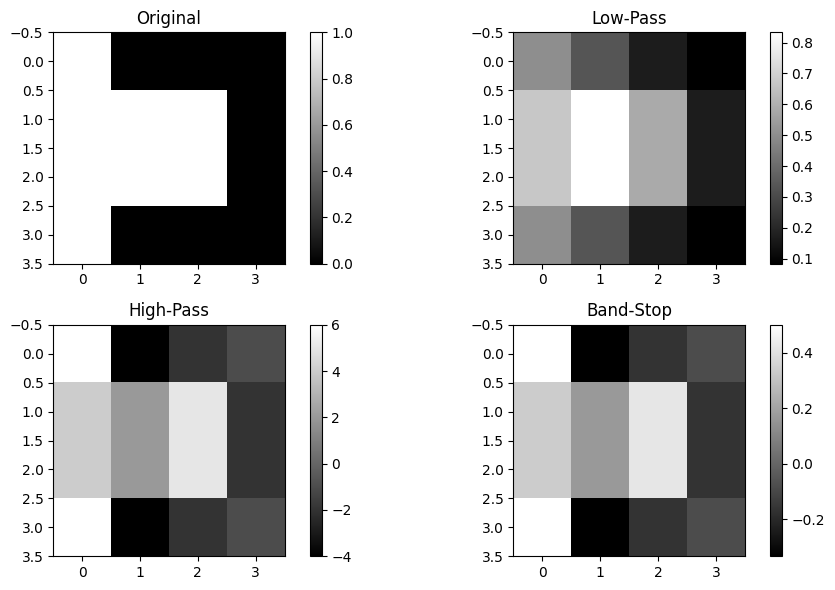

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# ======================
# 1. Input Matrix X
# ======================
X = np.array([
    [1, 0, 0, 0],
    [1, 1, 1, 0],
    [1, 1, 1, 0],
    [1, 0, 0, 0]
])

print("Matrix X:")
print(X)

# ======================
# 2. LOW-PASS FILTER
# ======================
H_low = np.array([
    [1, 1, 1],
    [1, 4, 1],
    [1, 1, 1]
]) / 12  # normalisasi

Y_low = convolve2d(X, H_low, mode='same', boundary='fill', fillvalue=0)

print("\nHasil Low-Pass:")
print(np.round(Y_low, 3))


# ======================
# 3. HIGH-PASS FILTER
# ======================
H_high = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

Y_high = convolve2d(X, H_high, mode='same', boundary='fill', fillvalue=0)

print("\nHasil High-Pass:")
print(Y_high)


# ======================
# 4. BAND-STOP FILTER
# ======================
# Band-stop sederhana = original - low-pass
Y_bandstop = X - Y_low

print("\nHasil Band-Stop:")
print(np.round(Y_bandstop, 3))


# ======================
# 5. VISUALISASI
# ======================
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.title("Original")
plt.imshow(X, cmap='gray')
plt.colorbar()

plt.subplot(2,2,2)
plt.title("Low-Pass")
plt.imshow(Y_low, cmap='gray')
plt.colorbar()

plt.subplot(2,2,3)
plt.title("High-Pass")
plt.imshow(Y_high, cmap='gray')
plt.colorbar()

plt.subplot(2,2,4)
plt.title("Band-Stop")
plt.imshow(Y_bandstop, cmap='gray')
plt.colorbar()

plt.tight_layout()
plt.show()